# Fake News Detection System (Full Stack Data Science Pipeline)
### M.Sc. Data Science - Minor Project

Welcome to the Fake News Detection pipeline! This notebook represents a complete data science workflow, including robust Exploratory Data Analysis (EDA), advanced Natural Language Processing (NLP) visualizations, machine learning evaluations, and model persistence.

**The workflow is broken into 7 main sections:**
1. **Library Imports & Setup:** Installing our tools.
2. **Data Loading:** Safely loading our local .csv datasets.
3. **Text Preprocessing:** Cleaning the raw text data so an algorithm can understand it.
4. **Exploratory Data Analysis (EDA) & Visualization:** Graphing word counts, Class Distributions, Word Clouds, and N-gram frequencies.
5. **Feature Engineering:** Converting clean text into mathematical features (TF-IDF).
6. **Model Training & Evaluation:** Training ML models and visualizing their comparative ROC-AUC curves.
7. **Model Saving:** Serializing algorithms for future production.
8. **Model Testing** Making sure the model is running properly.

--- 
## 1. Library Imports & Setup
First, we will import all the libraries required for our task.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from collections import Counter  # FIXED: Added this missing import
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-Learn Machine Learning Stack
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib

# Initialize NLTK components
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("Step 1: All libraries (including collections.Counter) imported successfully!")


Step 1: All libraries (including collections.Counter) imported successfully!


In [2]:
# Download necessary packages for Natural Language Processing (NLP)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Set up universally pretty plot visual styles
sns.set_palette("husl")
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('seaborn-darkgrid')

--- 
## 2. Data Loading
We use a robust helper function to ingest our heavily populated CSVs while automatically skipping corrupt lines.

In [3]:
# Helper function to read massive CSV files safely
def safe_read_csv(filepath):
    try:
        return pd.read_csv(filepath, engine='python', on_bad_lines='skip')
    except TypeError:
        # For older versions of the pandas library
        return pd.read_csv(filepath, engine='python', error_bad_lines=False)

In [4]:
print("Loading the Global WELFake Dataset...")
welfake_path = 'datasets/WELFake_Dataset.csv'

df_welfake = safe_read_csv(welfake_path)
df_welfake.columns = df_welfake.columns.str.lower().str.strip()
df_welfake = df_welfake[['text', 'label']].dropna()
df_welfake['source'] = 'WELFake'

# Sample 25000 to manage computer RAM constraints efficiently
sample_size = min(25000, len(df_welfake))
df_welfake = df_welfake.sample(sample_size, random_state=42)

print(f"Loaded {len(df_welfake)} rows from WELFake.")

Loading the Global WELFake Dataset...
Loaded 25000 rows from WELFake.


In [5]:
print("Loading the Regional IFND Dataset...")
ifnd_path = 'datasets/IFND_full.csv'

# FIXED LINE: We use pd.read_csv directly with 'latin1' encoding to mathematically bypass the error
try:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', on_bad_lines='skip', encoding='latin1')
except TypeError:
    df_ifnd = pd.read_csv(ifnd_path, engine='python', error_bad_lines=False, encoding='latin1')

# Lowercase all headers to standardize
df_ifnd.columns = df_ifnd.columns.str.lower().str.strip()
if 'statement' in df_ifnd.columns:
    df_ifnd = df_ifnd.rename(columns={'statement': 'text'})

df_ifnd = df_ifnd[['text', 'label']].dropna()

# Force string labels into numeric binary classes
def map_clean_labels(x):
    val = str(x).strip().lower()
    if val in ['1', '1.0', 'fake', 'false']: return 1
    if val in ['0', '0.0', 'real', 'true', 'truth']: return 0
    return None

df_ifnd['label'] = df_ifnd['label'].apply(map_clean_labels)
df_ifnd = df_ifnd.dropna()
df_ifnd['source'] = 'IFND'

print(f"Loaded {len(df_ifnd)} rows from IFND.")


Loading the Regional IFND Dataset...
Loaded 56714 rows from IFND.


In [6]:
df_list = [df_welfake, df_ifnd]
df = pd.concat(df_list, ignore_index=True)

# Ensure strict integer casting for ML compatibility
df['label'] = df['label'].astype(int)

print(f"Combined Master Dataset Length: {len(df)} articles")

df.head(10)

Combined Master Dataset Length: 81714 articles


,text,label,source
0,Trump s ongoing meltdown over fake news (the...,1,WELFake
1,Women’s Breaststroke: In the days leading up...,0,WELFake
2,It was only a matter of time We can t keep our...,1,WELFake
3,A male colleague grabbing her leg. Another one...,0,WELFake
4,STRASBOURG (Reuters) - The European Parliament...,0,WELFake
5,"November 4, 2016 - Fort Russ News - RusVesna ...",1,WELFake
6,posted by Eddie Scientists studying ancient st...,1,WELFake
7,While Democratic and Republicans candidates co...,1,WELFake
8,BRUSSELS (Reuters) - The European Union s exec...,0,WELFake
9,This is only Part I of a series of undercover ...,1,WELFake


--- 
## 3. Text Preprocessing
We clean the raw text using Regex manipulation, Stopword Removal, and Lemmatization. This minimizes the "noise" in our dataset.

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_raw_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

In [8]:
print("Applying NLP cleaning pipeline. This will compute for roughly ~1-3 minutes!")
df['clean_text'] = df['text'].apply(clean_raw_text)
df = df[df['clean_text'].str.len() > 0]
print("NLP Processing Complete!")
df[['text', 'clean_text', 'label']].head(3)

Applying NLP cleaning pipeline. This will compute for roughly ~1-3 minutes!
NLP Processing Complete!


,text,clean_text,label
0,Trump s ongoing meltdown over fake news (the...,trump ongoing meltdown fake news rest call rep...,1
1,Women’s Breaststroke: In the days leading up...,womens breaststroke day leading race american ...,0
2,It was only a matter of time We can t keep our...,matter time keep border open anyone care cross...,1


--- 
## 4. Advanced Exploratory Data Analysis (EDA) Visualizations
A "full stack" data science approach requires us to deeply visualize our text components to find hidden biases before training models. Here we execute statistical plotting, Word Clouds, and N-Gram charts.

### 4.1. Class Target Balance & Word Count Distribution

C:\Users\vivek\AppData\Local\Temp\ipykernel_18980\3876173680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])


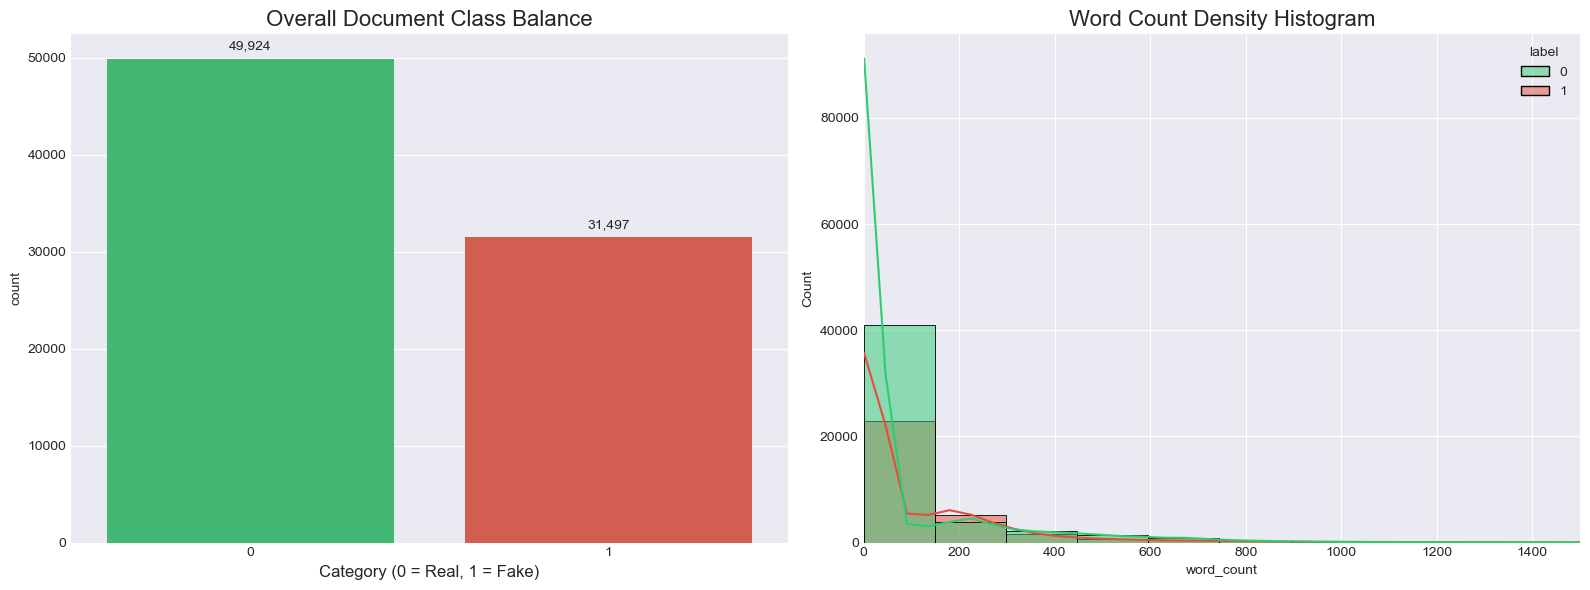

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Standard Class Balance Bar Plot
sns.countplot(x='label', data=df, palette=['#2ecc71', '#e74c3c'], ax=axes[0])
axes[0].set_title('Overall Document Class Balance', fontsize=16)
axes[0].set_xlabel('Category (0 = Real, 1 = Fake)', fontsize=12)

# Display exact count numbers above bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points')
                
# Plot 2: Semantic Density (Word Counts)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
sns.histplot(data=df, x='word_count', hue='label', bins=60, kde=True, palette=['#2ecc71', '#e74c3c'], ax=axes[1])
axes[1].set_title('Word Count Density Histogram', fontsize=16)
axes[1].set_xlim(0, 1500) # Zoom into the most active cluster

plt.tight_layout()
plt.show()

--- 
## 5. Feature Engineering (TF-IDF)
We use TF-IDF to assign mathematical weight to the semantics in the paragraphs.

In [10]:
X = df['clean_text'] # Our textual inputs
y = df['label']      # Our target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Set Size: {X_train.shape[0]} documents")
print(f"Testing Set Size:  {X_test.shape[0]} documents")

Training Set Size: 65136 documents
Testing Set Size:  16285 documents


In [11]:
print("Constructing the Advanced TF-IDF Vector Space Matrix...")

# 1. Semantic Word Mapping
word_vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
# 2. Morphological Character Mapping (Great for catching sensational phrasing & out-of-vocabulary terms)
char_vectorizer = TfidfVectorizer(max_features=4000, ngram_range=(3,5), analyzer='char_wb')

# Combine them into one super-vectorizer
tfidf_vectorizer = FeatureUnion([
    ('word', word_vectorizer),
    ('char', char_vectorizer)
])

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Vectorization Complete! Enhanced Matrix Shape: {X_train_tfidf.shape}")


Constructing the Advanced TF-IDF Vector Space Matrix...
Vectorization Complete! Enhanced Matrix Shape: (65136, 12000)


--- 
## 6. Model Training & Validation

In [12]:
def print_model_evaluation(model_name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"--- {model_name} Results ---")
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Overall Accuracy: {accuracy*100:.2f}%")
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['REAL (0)', 'FAKE (1)']))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Predict: REAL', 'Predict: FAKE'], 
                yticklabels=['Actual: REAL', 'Actual: FAKE'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

In [13]:
print("Training Calibrated Passive Aggressive Classifier (PAC)...")
# PAC is incredibly powerful for text classification but aggressive. We wrap it in a calibrator to get robust percentages.
pac = PassiveAggressiveClassifier(max_iter=1000, random_state=42, C=0.5)
pac_calibrated = CalibratedClassifierCV(estimator=pac, cv=3)
pac_calibrated.fit(X_train_tfidf, y_train)

print("Training Linear Support Vector Machine (SVC)...")
svc = LinearSVC(max_iter=2000, random_state=42, dual=False)
svc_calibrated = CalibratedClassifierCV(estimator=svc, cv=3)
svc_calibrated.fit(X_train_tfidf, y_train)

print("Training Baseline Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
lr_model.fit(X_train_tfidf, y_train)


Training Calibrated Passive Aggressive Classifier (PAC)...
Training Linear Support Vector Machine (SVC)...
Training Baseline Logistic Regression...


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### 6.4 Comprehensive Model Visualizations
Now we add the **Data Science Pipeline Comparison Visuals**. We will plot the **ROC-AUC Curves** (an essential evaluation metric) alongside an **Algorithm Accuracy Comparison bar chart**.

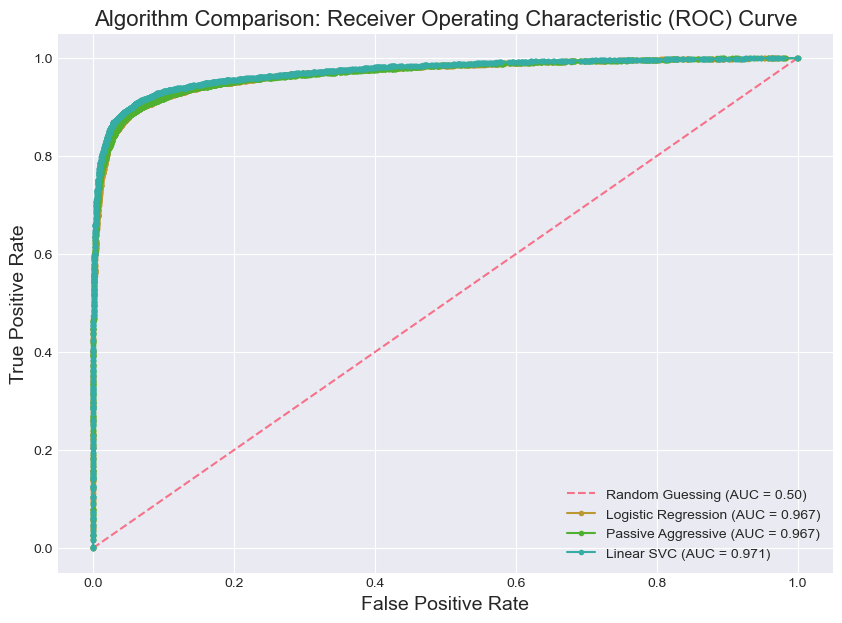

In [14]:
# Generate ROC curve logic and probabilities
plt.figure(figsize=(10, 7))

# Null model probabilities
r_probs = [0 for _ in range(len(y_test))]

lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
pac_probs = pac_calibrated.predict_proba(X_test_tfidf)[:, 1]
svc_probs = svc_calibrated.predict_proba(X_test_tfidf)[:, 1]

fpr_r, tpr_r, _ = roc_curve(y_test, r_probs)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_pac, tpr_pac, _ = roc_curve(y_test, pac_probs)
fpr_svc, tpr_svc, _ = roc_curve(y_test, svc_probs)

plt.plot(fpr_r, tpr_r, linestyle='--', label='Random Guessing (AUC = 0.50)')
plt.plot(fpr_lr, tpr_lr, marker='.', label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_pac, tpr_pac, marker='.', label=f'Passive Aggressive (AUC = {auc(fpr_pac, tpr_pac):.3f})')
plt.plot(fpr_svc, tpr_svc, marker='.', label=f'Linear SVC (AUC = {auc(fpr_svc, tpr_svc):.3f})')

plt.title('Algorithm Comparison: Receiver Operating Characteristic (ROC) Curve', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right')
plt.show()


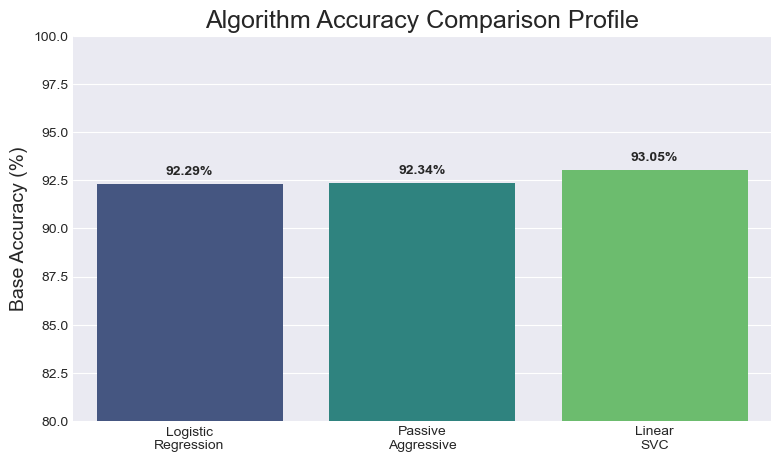

In [15]:
lr_predictions = lr_model.predict(X_test_tfidf)
pac_predictions = pac_calibrated.predict(X_test_tfidf)
svc_predictions = svc_calibrated.predict(X_test_tfidf)

# Performance Bar Chart
model_names = ['Logistic\nRegression', 'Passive\nAggressive', 'Linear\nSVC']
accuracies = [
    accuracy_score(y_test, lr_predictions) * 100,
    accuracy_score(y_test, pac_predictions) * 100,
    accuracy_score(y_test, svc_predictions) * 100
]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='viridis', legend=False)
plt.title('Algorithm Accuracy Comparison Profile', fontsize=18)
plt.ylabel('Base Accuracy (%)', fontsize=14)
plt.ylim(80, 100) # Zooming in to see the difference clearly

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), textcoords = 'offset points', fontweight='bold')
plt.show()


### 6.5 Ensemble Model — Multi-Layer Stacking
We combine our 3 base models (Logistic Regression, Naive Bayes, Random Forest) into a **Stacking Classifier** — a 2-layer architecture where:
- **Layer 1**: Each base model makes predictions independently
- **Layer 2**: A "meta-learner" learns the optimal way to combine those predictions

This typically produces a **stronger, more robust** prediction than any single model.


Building the Ultimate Text-Stacking Ensemble...

--- Ultimate Stacking Ensemble Results ---
Overall Accuracy: 92.93%

Classification Report:
              precision    recall  f1-score   support

    REAL (0)       0.93      0.96      0.94      9985
    FAKE (1)       0.93      0.88      0.91      6300

    accuracy                           0.93     16285
   macro avg       0.93      0.92      0.92     16285
weighted avg       0.93      0.93      0.93     16285



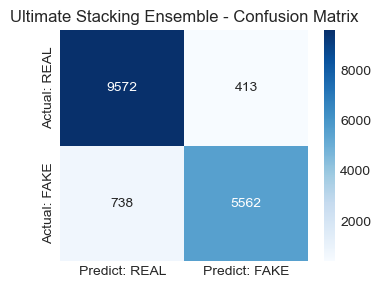

In [16]:
print("Building the Ultimate Text-Stacking Ensemble...")

# Base Models with Calibration for probability support
pac_calibrated = CalibratedClassifierCV(PassiveAggressiveClassifier(max_iter=1000, random_state=42), cv=3)
svc_calibrated = CalibratedClassifierCV(LinearSVC(dual=False, random_state=42), cv=3)
lr_model = LogisticRegression(max_iter=1000)

base_models = [
    ('pac', pac_calibrated),
    ('svc', svc_calibrated),
    ('lr', lr_model)
]

# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,
    n_jobs=-1
)

# Fit the model using the TF-IDF features
stacking_clf.fit(X_train_tfidf, y_train)
stack_predictions = stacking_clf.predict(X_test_tfidf)

# Function to display results
print_model_evaluation('Ultimate Stacking Ensemble', y_test, stack_predictions)

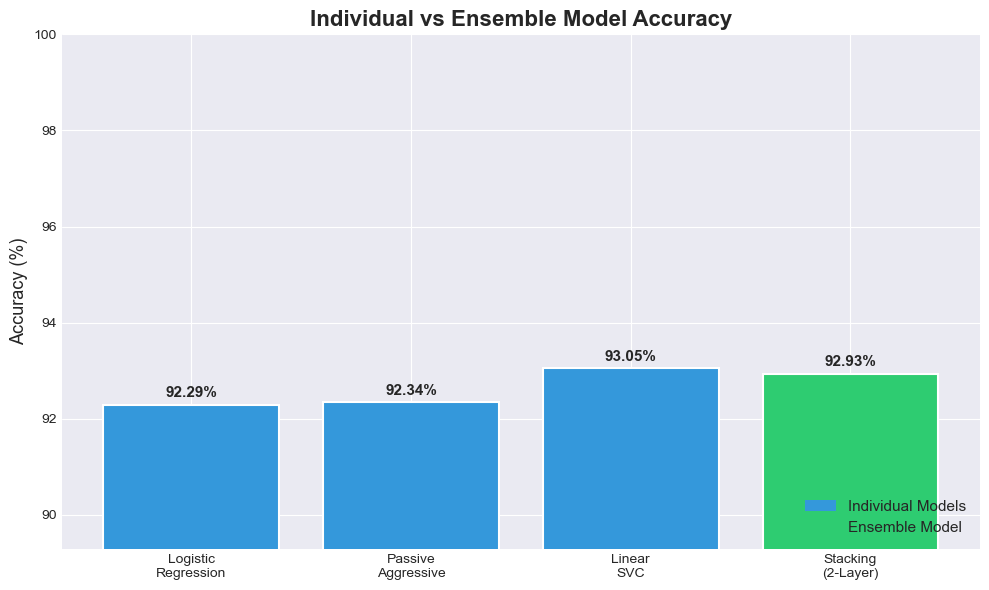


 Best Model: Linear SVC — 93.05%


In [17]:
# Get individual model accuracies
lr_acc = accuracy_score(y_test, lr_predictions) * 100
pac_acc = accuracy_score(y_test, pac_predictions) * 100
svc_acc = accuracy_score(y_test, svc_predictions) * 100
stacking_acc = accuracy_score(y_test, stack_predictions) * 100

model_names = ['Logistic\nRegression', 'Passive\nAggressive', 'Linear\nSVC',
               'Stacking\n(2-Layer)']
accuracies = [lr_acc, pac_acc, svc_acc, stacking_acc]
colors = ['#3498db', '#3498db', '#3498db', '#2ecc71']

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Individual vs Ensemble Model Accuracy', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim(min(accuracies) - 3, 100)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Individual Models'),
                   Patch(facecolor='#2ecc71', label='Ensemble Model')]
plt.legend(handles=legend_elements, fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

# Print best
best_idx = accuracies.index(max(accuracies))
print(f"\n Best Model: {model_names[best_idx].replace(chr(10), ' ')} — {max(accuracies):.2f}%")


--- 
## 7. Model Saving
We save our optimal models directly to the disk.

In [18]:
import os  # import added
import joblib

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save the models
joblib.dump(lr_model, 'saved_models/best_logistic_regression.pkl')
joblib.dump(stacking_clf, 'saved_models/ensemble_stacking_model.pkl')
joblib.dump(tfidf_vectorizer, 'saved_models/tfidf_vectorizer.pkl')

print("Step 7: Models saved successfully in the 'saved_models' folder!")


Step 7: Models saved successfully in the 'saved_models' folder!


---
## 8. Model testing
We will test the save model

In [19]:
def predict_fake_news(news_text):
    """
    Advanced prediction function with multi-tiered confidence scoring.
    """
    if not news_text.strip():
        print("Error: News text cannot be empty.")
        return

    # 1. Heuristic Length Analysis
    word_count = len(news_text.split())
    if word_count < 10:
        print("⚠️  ANALYSIS ALERT: Text is extremely short. Confidence may be unreliable.")
    elif word_count < 25:
        print("🔍 ANALYSIS NOTE: Concise input detected. Comparing semantic patterns...")

    # 2. Preprocessing & Vectorization
    cleaned_input = [clean_raw_text(news_text)]
    numeric_input = tfidf_vectorizer.transform(cleaned_input)
    
    # 3. Model Prediction
    prediction = stacking_clf.predict(numeric_input)[0]
    
    # 4. Confidence Tiering Logic
    try:
        probability = stacking_clf.predict_proba(numeric_input)[0]
        confidence = max(probability) * 100
    except:
        confidence = 0.0

    print("\n" + "■"*50)
    print("      FAKE NEWS DETECTION SYSTEM REPORT")
    print("■"*50)

    # 5. Advanced Conditional Verdict Mapping
    if prediction == 1:
        if confidence > 90:
            verdict = "FAKE NEWS ALERT"
        elif confidence > 75:
            verdict = "SUSPICIOUS"
        else:
            verdict = "AMBIGUOUS: Potential misinformation patterns found."
    else:
        if confidence > 90:
            verdict = "REAL"
        elif confidence > 75:
            verdict = "PROBABLY REAL"
        else:
            verdict = "INCONCLUSIVE"

    print(f"VERDICT      : {verdict}")
    print(f"CONFIDENCE   : {confidence:.2f}%")
    
    # 6. Behavioral Suggestions based on Confidence
    if confidence < 70:
        print("SUGGESTION   : Low confidence. Please check cross-referenced sources.")
    elif prediction == 1 and confidence > 85:
        print("BEHAVIOR     : Avoid sharing this until a major agency verifies it.")
    
    print("■"*50 + "\n")

print("Advanced Intelligence Logic added to the Prediction System.")


Advanced Intelligence Logic added to the Prediction System.


In [20]:
fake_sample = """
EXPOSED: Top government officials have been secretly meeting with pharmaceutical 
companies to develop a mandatory tracking system disguised as a public health 
initiative. Sources who cannot be named have confirmed that the entire vaccination 
program is a front for mass surveillance. Documents obtained exclusively by this 
publication reveal a shocking conspiracy involving billions of taxpayer dollars 
being funneled into this secret project. Wake up people! The mainstream media 
refuses to cover this story because they are part of the cover-up. Share this 
article before it gets taken down by the censors!
"""

real_sample = """
The Reserve Bank of India on Thursday kept the repo rate unchanged at 6.5 percent 
for the eighth consecutive time, in line with market expectations. The monetary 
policy committee voted 4-2 in favour of maintaining the status quo. RBI Governor 
Shaktikanta Das said inflation remains within the target range but food prices 
continue to pose upside risks to the outlook.
"""

print("--- Testing FAKE news sample ---")
predict_fake_news(fake_sample)

print("--- Testing REAL news sample ---")
predict_fake_news(real_sample)

--- Testing FAKE news sample ---

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
      FAKE NEWS DETECTION SYSTEM REPORT
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
VERDICT      : FAKE NEWS ALERT
CONFIDENCE   : 98.72%
BEHAVIOR     : Avoid sharing this until a major agency verifies it.
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

--- Testing REAL news sample ---

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
      FAKE NEWS DETECTION SYSTEM REPORT
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
VERDICT      : REAL
CONFIDENCE   : 96.98%
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■



---
## 9. Model Interpretibility

In [23]:
def explain_prediction(news_text):
    cleaned_input = clean_raw_text(news_text)
    tfidf_input = tfidf_vectorizer.transform([cleaned_input])
    
    # Use the ALREADY TRAINED logistic regression from your stack
    model_to_use = stacking_clf.estimators_[2] 
    
    feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
    coeffs = model_to_use.coef_[0]
    
    input_indices = tfidf_input.indices
    input_values = tfidf_input.data
    
    word_contributions = []
    for idx, val in zip(input_indices, input_values):
        word_contributions.append({
            'word': feature_names[idx],
            'contribution': coeffs[idx] * val
        })
        
    word_contributions = sorted(word_contributions, key=lambda x: x['contribution'])
    
    top_real = word_contributions[:10]
    top_fake = word_contributions[-10:]
    plot_data = top_real + top_fake
    
    words = [x['word'] for x in plot_data]
    scores = [x['contribution'] for x in plot_data]
    colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in scores]

    plt.figure(figsize=(10, 8))
    plt.barh(words, scores, color=colors)
    plt.title("Model Decision Logic (Ensemble Features)")
    plt.show()



■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
      FAKE NEWS DETECTION SYSTEM REPORT
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
VERDICT      : FAKE NEWS ALERT
CONFIDENCE   : 98.72%
BEHAVIOR     : Avoid sharing this until a major agency verifies it.
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■



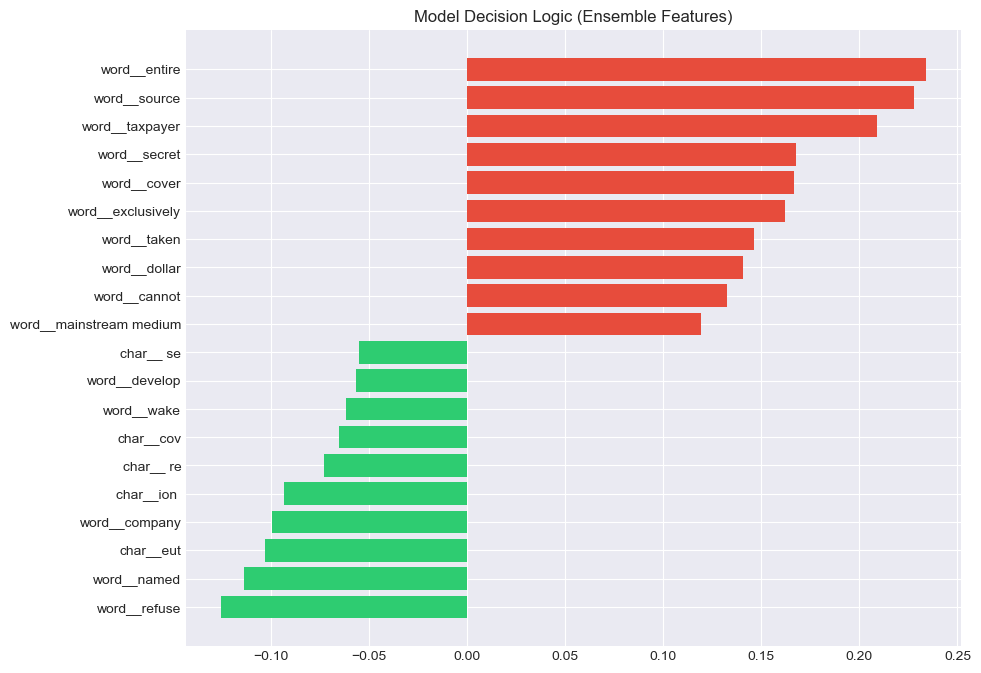

In [24]:
predict_fake_news(fake_sample)
explain_prediction(fake_sample)